# ECG fold-0 loss comparison

The original notebook 2.1 model scored better on fold 0 than the new notebook 2.3 fold-0 model. This short experiment tests whether the focal-loss calculation explains the difference.

Running all cells trains two fold-0 models using development data only. The two runs use the same starting setup and differ only in how focal loss is calculated.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ecg_loss_comparison import run_fold0_loss_comparison

MODEL_DIR = PROJECT_ROOT / "models/ecg_loss_comparison/seed42"
RESULT_DIR = PROJECT_ROOT / "analysis_outputs/ecg_loss_comparison/seed42"
print(f"Project: {PROJECT_ROOT}")

Project: E:\Deep Learning\CardioFusion


## Fair comparison

Both runs use folds 1–4 for training and fold 0 for validation. They use seed 42, the same initial weights and random states, the same patient and batch order, and the same model, optimizer, scheduler, and stopping rule.

The only intended difference is the focal-loss calculation:

- **Original notebook loss:** calculates sigmoid probabilities directly.
- **Shared source loss:** calculates the same true-class probability from binary cross-entropy.

The formulas mean the same thing mathematically, but their small numerical differences may lead training down different paths. No community-test files are loaded. Existing outputs are never overwritten.

## Run the two fold-0 models

In [2]:
run_fold0_loss_comparison(PROJECT_ROOT)
print(f"Finished. Results saved in: {RESULT_DIR}")

original_notebook_loss | epoch 1 | loss 0.0524 | validation AUROC 0.7879 | AUPRC 0.3538


original_notebook_loss | epoch 2 | loss 0.0324 | validation AUROC 0.8788 | AUPRC 0.4616


original_notebook_loss | epoch 3 | loss 0.0223 | validation AUROC 0.8759 | AUPRC 0.3901


original_notebook_loss | epoch 4 | loss 0.0248 | validation AUROC 0.8996 | AUPRC 0.4287


original_notebook_loss | epoch 5 | loss 0.0249 | validation AUROC 0.8712 | AUPRC 0.3803


...

shared_src_loss | epoch 20 | loss 0.0012 | validation AUROC 0.9015 | AUPRC 0.5082


shared_src_loss | epoch 21 | loss 0.0012 | validation AUROC 0.8977 | AUPRC 0.4934


shared_src_loss | epoch 22 | loss 0.0013 | validation AUROC 0.8968 | AUPRC 0.4885


shared_src_loss | epoch 23 | loss 0.0009 | validation AUROC 0.8987 | AUPRC 0.5036


Finished. Results saved in: E:\Deep Learning\CardioFusion\analysis_outputs\ecg_loss_comparison\seed42


## Validation results

AUROC and AUPRC do not depend on a classification cutoff, so they are the main measures for explaining the earlier performance difference. Recall and specificity are also shown for the two new runs using each run's fold-0 F1 cutoff.

In [3]:
summary = pd.read_csv(RESULT_DIR / "comparison_summary.csv")
names = {
    "original": "Saved original notebook 2.1",
    "new_fold0": "Saved notebook 2.3 fold 0",
    "original_notebook_loss": "New run: original loss",
    "shared_src_loss": "New run: shared loss",
}
summary["display_name"] = summary["model"].map(names)
display(summary[[
    "display_name", "result_type", "best_epoch", "epochs_run",
    "auroc", "auprc", "training_seconds",
]].round(4))
display(summary[summary.result_type.eq("controlled_new_run")][[
    "display_name", "threshold", "recall", "specificity",
    "balanced_accuracy", "precision", "f1", "tn", "fp", "fn", "tp",
]].round(4))

setup = json.loads((RESULT_DIR / "setup_checks.json").read_text(encoding="utf-8"))
assert setup["all_equal"] and setup["development_only"]
display(pd.Series(setup["checks"], name="matched").to_frame())

,display_name,result_type,best_epoch,epochs_run,auroc,auprc,training_seconds
0,Saved original notebook 2.1,saved_checkpoint_replay,23,33,0.9564,0.7686,NaN
1,Saved notebook 2.3 fold 0,saved_checkpoint_replay,13,23,0.9110,0.4739,NaN
2,New run: original loss,controlled_new_run,23,33,0.9564,0.7686,67.3615
3,New run: shared loss,controlled_new_run,13,23,0.9110,0.4739,42.2461


,display_name,threshold,recall,specificity,balanced_accuracy,precision,f1,tn,fp,fn,tp
2,New run: original loss,0.4982,0.9167,0.9091,0.9129,0.5789,0.7097,80.0,8.0,1.0,11.0
3,New run: shared loss,0.5257,0.7500,0.9205,0.8352,0.5625,0.6429,81.0,7.0,3.0,9.0


,matched
initial_model_state,True
initial_cpu_random_state,True
initial_gpu_random_state,True
initial_shuffle_state,True
training_patient_order,True
validation_patient_order,True


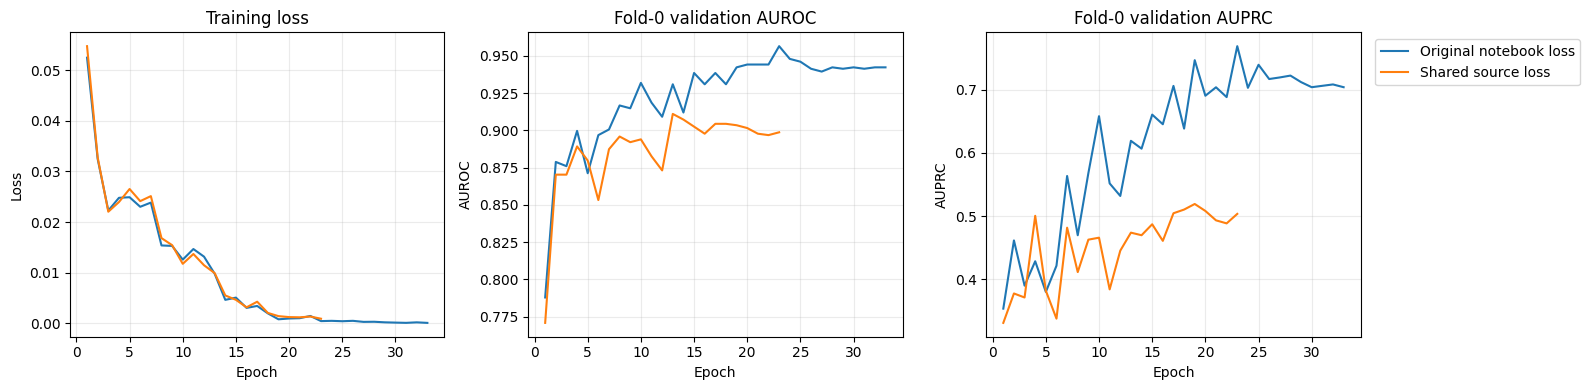

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for loss_name, label in (
    ("original_notebook_loss", "Original notebook loss"),
    ("shared_src_loss", "Shared source loss"),
):
    history = pd.read_csv(MODEL_DIR / loss_name / "history.csv")
    axes[0].plot(history.epoch, history.train_loss, label=label)
    axes[1].plot(history.epoch, history.val_auroc, label=label)
    axes[2].plot(history.epoch, history.val_auprc, label=label)
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Fold-0 validation AUROC", xlabel="Epoch", ylabel="AUROC")
axes[2].set(title="Fold-0 validation AUPRC", xlabel="Epoch", ylabel="AUPRC")
for axis in axes:
    axis.grid(alpha=0.25)
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Observations and decision

The loss calculation explains the fold-0 difference in this controlled setup.

- The new run with the original notebook loss exactly reproduced the saved notebook 2.1 result: AUROC 0.9564, AUPRC 0.7686, best epoch 23, and 33 epochs run. Its saved weights, common history values, and all 100 validation probabilities also match exactly.
- The new run with the shared source loss exactly reproduced the saved notebook 2.3 fold-0 result: AUROC 0.9110, AUPRC 0.4739, best epoch 13, and 23 epochs run. Its weights, history, and validation probabilities also match exactly.
- Both controlled runs started with matching weights, random states, shuffle state, and patient order. No community-test data was loaded.

The formulas mean the same thing mathematically, but use slightly different floating-point operations. The resulting tiny gradient differences led training along different paths. This proves why these two deterministic fold-0 runs differ. It does not prove that the original calculation is generally better across every fold, seed, or modality.

**Current decision:** keep the original ECG and PCG models as the project baselines. Preserve both controlled runs and the five-fold results. The PCG five-fold run has since completed; its results and limits are recorded in notebook 3.2.

If the five-fold comparison is revisited, use each original notebook's exact loss calculation. For PCG, also control the random training-crop sequence. This is a possible follow-up, not a required rerun or proof that either loss is generally better. The production loss implementation remains unchanged.

## Saved files

Each new run has its own `best_model.pt`, `history.csv`, `validation_predictions.csv`, and `settings.json` under `models/ecg_loss_comparison/seed42`.

`comparison_summary.csv` contains the two new results and the two saved-model replays. `setup_checks.json` confirms that the controlled runs started with matching weights, random states, shuffle state, and patient order.

This is one paired fold-0 comparison. It can show whether the loss calculation changes this run, but one fold and one seed cannot establish that either implementation is generally better.